# Phase 1 — AQICN Ground Station Data Preparation
**Project:** Mining Spatio-Temporal Patterns and Predicting Air Pollution in Iran  
**Input:** 200 station CSV files + coordinates file  
**Output:** `master_ground.csv` — clean, merged dataset ready for Phase 2

## 0. Imports & Configuration

In [15]:
import pandas as pd
import numpy as np
import os
import glob
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── CONFIGURE THESE PATHS ──────────────────────────────────────────────────────
STATIONS_DIR = 'F:1405-03-07/Phase-I/Stations'             # folder containing all station CSV files
COORDS_FILE  = 'F:1405-03-07/Phase-I/Data/aqi_stations.xlsx'  # coordinates + metadata file
OUTPUT_FILE  = 'F:1405-03-07/Phase-I/Output/Final/1/master_ground.csv'     # final merged output
REPORT_FILE  = 'F:SBU/1405-03-07/Phase-I/Output/Final/1/phase1_report.csv'     # per-station quality report
# ──────────────────────────────────────────────────────────────────────────────

# Pollutant columns expected (lowercase)
POLLUTANTS = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

print('Configuration ready.')
print(f'  Station folder : {STATIONS_DIR}')
print(f'  Coordinates    : {COORDS_FILE}')
print(f'  Output file    : {OUTPUT_FILE}')

Configuration ready.
  Station folder : F:/1405-03-07/Phase-I/Stations
  Coordinates    : F:/1405-03-07/Phase-I/Data/aqi_stations.xlsx
  Output file    : F:/1405-03-07/Phase-I/Output/Final/1/master_ground.csv


## 1. Load Coordinates File

In [16]:
# Read coordinates — header is on row 2 (index 1)
coords_raw = pd.read_excel(COORDS_FILE, header=0)

# Rename to standard column names
coords = coords_raw.rename(columns={
    coords_raw.columns[0]: 'index',
    coords_raw.columns[1]: 'station_id',
    coords_raw.columns[2]: 'station_name',
    coords_raw.columns[3]: 'latitude',
    coords_raw.columns[4]: 'longitude'
}).drop(columns=[c for c in coords_raw.columns[6:]], errors='ignore')

# Drop rows with no station_id
coords = coords.dropna(subset=['station_id']).reset_index(drop=True)
coords['station_id'] = coords['station_id'].astype(str).str.strip()

print(f'Coordinates loaded : {len(coords)} stations')
print(f'Missing lat/lon    : {coords[["latitude","longitude"]].isna().any(axis=1).sum()} stations')
coords.head()

Coordinates loaded : 200 stations
Missing lat/lon    : 0 stations


,index,station_id,station_name,latitude,longitude
0,1,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848
1,2,"abhar,-abhar, zanjan, iran-air-quality","abhar,-abhar, zanjan, iran-air-quality",36.146850,49.240930
2,3,"abresan,-tabriz, az-east, iran-air-quality","abresan,-tabriz, az-east, iran-air-quality",38.063956,46.322959
3,4,"ahmad-abad, isfahan, isfahan, iran-air-quality","ahmad-abad, isfahan, isfahan, iran-air-quality",32.664032,51.701288
4,5,"ahvaz,-ahvaz, khouzestan, iran-air-quality","ahvaz,-ahvaz, khouzestan, iran-air-quality",31.308503,48.643601


## 2. Discover Station CSV Files

In [17]:
# Build lookup: station_id (filename without .csv) -> full path
csv_paths  = glob.glob(os.path.join(STATIONS_DIR, '*.csv'))
csv_lookup = {os.path.splitext(os.path.basename(p))[0]: p for p in csv_paths}

print(f'CSV files found: {len(csv_lookup)}')

coords['csv_found'] = coords['station_name'].map(lambda x: x in csv_lookup)
matched   = coords['csv_found'].sum()
unmatched = (~coords['csv_found']).sum()
print(f'Matched          : {matched}')
print(f'Unmatched        : {unmatched}')

if unmatched > 0:
    print('\nUnmatched station IDs (check filename spelling):')
    print(coords[~coords['csv_found']][['station_id', 'station_name']].to_string(index=False))

CSV files found: 200
Matched          : 200
Unmatched        : 0


## 3. Load & Parse All Station Files

In [18]:
def load_station_csv(path: str, station_id: str) -> pd.DataFrame:
    """
    Load one station CSV. Handles:
    - Variable columns (not all stations have all pollutants)
    - Whitespace in column names and cell values
    - Multiple date formats (YYYY/M/D, M/D/YYYY, YYYY-MM-DD)
    - Completely empty pollutant cells -> NaN
    """
    try:
        df = pd.read_csv(path, skipinitialspace=True)
    except Exception as e:
        print(f'  [ERROR] Cannot read {station_id}: {e}')
        return pd.DataFrame()

    if df.empty:
        return pd.DataFrame()

    # Normalize column names
    df.columns = [c.strip().lower() for c in df.columns]

    if 'date' not in df.columns:
        print(f'  [WARN] No date column in {station_id}')
        return pd.DataFrame()

    # Parse dates
    df['date'] = pd.to_datetime(
        df['date'].astype(str).str.strip(),
        infer_datetime_format=True,
        errors='coerce'
    )
    df = df.dropna(subset=['date'])

    # Convert pollutants to numeric; add missing ones as NaN
    for p in POLLUTANTS:
        if p in df.columns:
            df[p] = pd.to_numeric(
                df[p].astype(str).str.strip().replace('', np.nan),
                errors='coerce'
            )
        else:
            df[p] = np.nan

    df['station_id'] = station_id
    return df[['station_id', 'date'] + POLLUTANTS].copy()


# Load all matched stations
frames      = []
report_rows = []

for _, row in coords[coords['csv_found']].iterrows():
    sid  = row['station_id']
    path = csv_lookup[sid]
    df   = load_station_csv(path, sid)

    if df.empty:
        report_rows.append({'station_id': sid, 'n_rows': 0,
                            **{f'{p}_coverage_%': 0 for p in POLLUTANTS}})
        continue

    n        = len(df)
    coverage = {f'{p}_coverage_%': round(df[p].notna().sum() / n * 100, 1)
                for p in POLLUTANTS}
    report_rows.append({'station_id': sid, 'n_rows': n, **coverage})
    frames.append(df)

print(f'Successfully loaded : {len(frames)} station files')
print(f'Failed / empty      : {coords["csv_found"].sum() - len(frames)}')

Successfully loaded : 200 station files
Failed / empty      : 0


## 4. Merge All Stations into One DataFrame

In [20]:
# Concatenate all station dataframes
master = pd.concat(frames, ignore_index=True)

# Join coordinates
master = master.merge(
    coords[['station_id', 'station_name', 'latitude', 'longitude']],
    on='station_id',
    how='left'
)

# Sort
master = master.sort_values(['station_id', 'date']).reset_index(drop=True)

# Add time features (needed for Phase 4 ML)
master['year']   = master['date'].dt.year
master['month']  = master['date'].dt.month
master['day']    = master['date'].dt.day
master['season'] = master['month'].map({
    12: 'winter', 1: 'winter', 2: 'winter',
     3: 'spring', 4: 'spring', 5: 'spring',
     6: 'summer', 7: 'summer', 8: 'summer',
     9: 'autumn', 10: 'autumn', 11: 'autumn'
})

print(f'Master shape  : {master.shape}')
print(f'Date range    : {master["date"].min().date()} -> {master["date"].max().date()}')
print(f'Stations      : {master["station_id"].nunique()}')
master.head()

Master shape  : (331042, 15)
Date range    : 2015-02-06 -> 2025-07-22
Stations      : 200


,station_id,date,pm25,pm10,no2,so2,co,o3,station_name,latitude,longitude,year,month,day,season
0,"abadan,-abadan, khouzestan, iran-air-quality",2018-06-05,NaN,89.0,NaN,NaN,NaN,NaN,"abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018,6,5,summer
1,"abadan,-abadan, khouzestan, iran-air-quality",2018-06-06,NaN,103.0,NaN,NaN,NaN,NaN,"abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018,6,6,summer
2,"abadan,-abadan, khouzestan, iran-air-quality",2018-06-07,NaN,77.0,NaN,NaN,NaN,NaN,"abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018,6,7,summer
3,"abadan,-abadan, khouzestan, iran-air-quality",2018-06-08,NaN,99.0,NaN,NaN,NaN,NaN,"abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018,6,8,summer
4,"abadan,-abadan, khouzestan, iran-air-quality",2018-06-09,NaN,128.0,NaN,NaN,NaN,NaN,"abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018,6,9,summer


## 5. Data Quality Analysis

In [21]:
print('=' * 55)
print('MISSING DATA SUMMARY')
print('=' * 55)

total = len(master)
for p in POLLUTANTS:
    n_valid   = master[p].notna().sum()
    n_missing = total - n_valid
    pct       = n_missing / total * 100
    bar       = 'X' * int((100 - pct) / 5)
    print(f'  {p.upper():<6}: {n_valid:>7,} valid | {n_missing:>7,} missing ({pct:5.1f}% missing) {bar}')

print()
all_missing = master[POLLUTANTS].isna().all(axis=1).sum()
print(f'Rows with ALL pollutants missing: {all_missing:,} ({all_missing/total*100:.1f}%)')

MISSING DATA SUMMARY
  PM25  : 209,337 valid | 121,705 missing ( 36.8% missing) XXXXXXXXXXXX
  PM10  : 189,870 valid | 141,172 missing ( 42.6% missing) XXXXXXXXXXX
  NO2   : 124,123 valid | 206,919 missing ( 62.5% missing) XXXXXXX
  SO2   : 125,950 valid | 205,092 missing ( 62.0% missing) XXXXXXX
  CO    : 128,963 valid | 202,079 missing ( 61.0% missing) XXXXXXX
  O3    :  26,864 valid | 304,178 missing ( 91.9% missing) X

Rows with ALL pollutants missing: 21,957 (6.6%)


In [22]:
# Per-station coverage report
report_df = pd.DataFrame(report_rows)
print('Per-station coverage (%) summary:')
print(report_df.describe().round(1).to_string())

# Flag stations with very poor PM2.5 coverage
poor = report_df[report_df['pm25_coverage_%'] < 20]
print(f'\nStations with PM2.5 coverage < 20%: {len(poor)}')
if not poor.empty:
    print(poor[['station_id', 'pm25_coverage_%', 'n_rows']].to_string(index=False))

Per-station coverage (%) summary:
       n_rows  pm25_coverage_%  pm10_coverage_%  no2_coverage_%  so2_coverage_%  co_coverage_%  o3_coverage_%
count   200.0            200.0            200.0           200.0           200.0          200.0          200.0
mean   1655.2             60.4             55.7            31.5            33.1           34.4            7.0
std     632.1             34.5             38.2            33.6            35.1           34.4           15.0
min      15.0              0.0              0.0             0.0             0.0            0.0            0.0
25%    1317.5             32.8              0.6             0.0             0.0            0.0            0.0
50%    1776.5             79.1             75.7            14.6            10.9           23.7            0.0
75%    2117.0             87.2             86.8            66.6            69.1           70.8            6.2
max    3169.0            100.0            100.0            88.4            92.7       

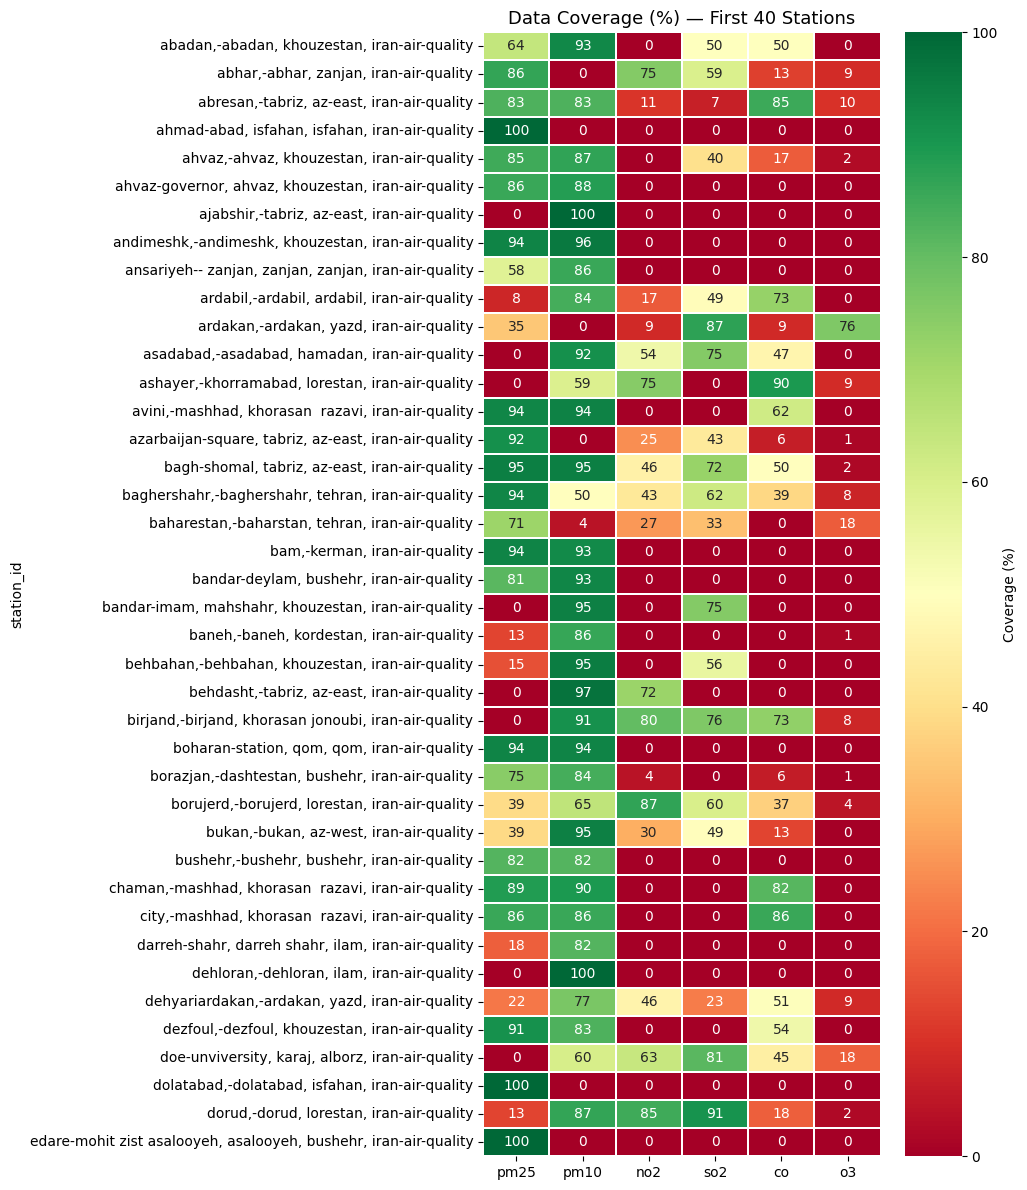

In [29]:
# Coverage heatmap (first 40 stations)
sample_stations = master['station_id'].unique()[:40]

coverage_matrix = (
    master[master['station_id'].isin(sample_stations)]
    .groupby('station_id')[POLLUTANTS]
    .apply(lambda df: df.notna().mean() * 100)
)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(coverage_matrix, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Coverage (%)'})
ax.set_title('Data Coverage (%) — First 40 Stations', fontsize=13)
plt.tight_layout()
plt.savefig('F:/Amin Ahamadzade/SBU/1405-03-07/Phase-I/Output/Final/1/phase1_coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cleaning
Rules:
1. Remove duplicate (station_id, date) — keep first occurrence
2. Remove rows where ALL pollutants are NaN
3. Set physically impossible values to NaN (negatives or > 999)

In [24]:
n0 = len(master)

# Rule 1: dedup
master = master.drop_duplicates(subset=['station_id', 'date'], keep='first')
print(f'After dedup         : {len(master):,} rows (removed {n0 - len(master):,})')

# Rule 2: all-NaN rows
n1 = len(master)
master = master[~master[POLLUTANTS].isna().all(axis=1)]
print(f'After all-NaN drop  : {len(master):,} rows (removed {n1 - len(master):,})')

# Rule 3: impossible values
for p in POLLUTANTS:
    n_bad = ((master[p] < 0) | (master[p] > 999)).sum()
    if n_bad:
        print(f'  {p.upper()}: {n_bad} impossible values set to NaN')
    master[p] = master[p].where((master[p] >= 0) & (master[p] <= 999))

print(f'\nFinal clean shape   : {master.shape}')

After dedup         : 331,042 rows (removed 0)
After all-NaN drop  : 309,085 rows (removed 21,957)

Final clean shape   : (309085, 15)


## 7. Temporal Coverage Plot

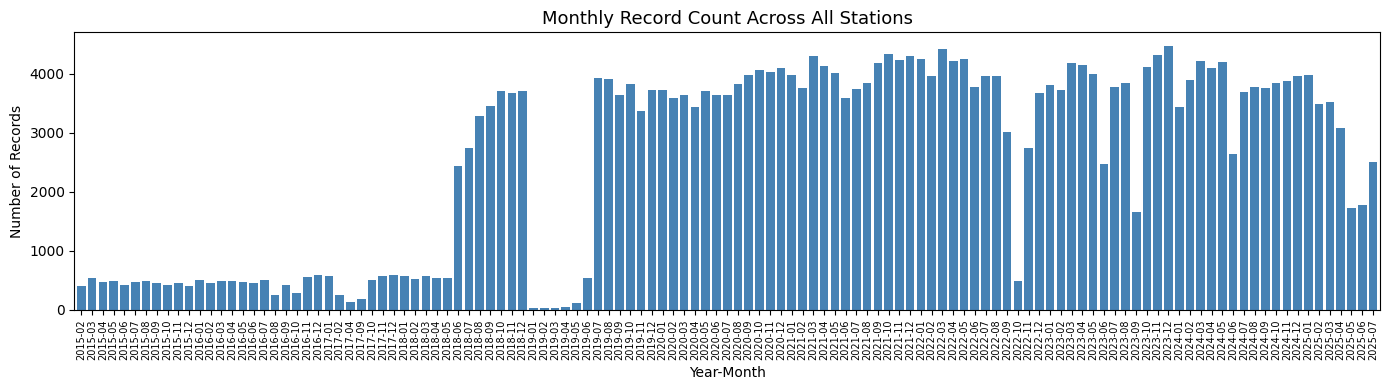

In [30]:
monthly_counts = master.groupby(master['date'].dt.to_period('M')).size()

fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(kind='bar', ax=ax, color='steelblue', width=0.8)
ax.set_title('Monthly Record Count Across All Stations', fontsize=13)
ax.set_xlabel('Year-Month')
ax.set_ylabel('Number of Records')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.savefig('F:/Amin Ahamadzade/SBU/1405-03-07/Phase-I/Output/Final/1/phase1_temporal_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Outputs

In [26]:
# Final column order
final_cols = [
    'station_id', 'station_name',
    'latitude', 'longitude',
    'date', 'year', 'month', 'day', 'season',
    'pm25', 'pm10', 'no2', 'so2', 'co', 'o3'
]
master = master[final_cols]

# Save
master.to_csv(OUTPUT_FILE, index=False, encoding='utf-8-sig')
print(f'master_ground.csv saved  -> {OUTPUT_FILE}')
print(f'  Shape      : {master.shape}')
print(f'  Stations   : {master["station_id"].nunique()}')
print(f'  Date range : {master["date"].min().date()} -> {master["date"].max().date()}')

report_df.to_csv(REPORT_FILE, index=False)
print(f'\nphase1_report.csv saved  -> {REPORT_FILE}')

master.head(10)

master_ground.csv saved  -> F:/Amin Ahamadzade/SBU/1405-03-07/Phase-I/Output/Final/1/master_ground.csv
  Shape      : (309085, 15)
  Stations   : 200
  Date range : 2015-02-06 -> 2025-07-22

phase1_report.csv saved  -> F:/Amin Ahamadzade/SBU/1405-03-07/Phase-I/Output/Final/1/phase1_report.csv


,station_id,station_name,latitude,longitude,date,year,month,day,season,pm25,pm10,no2,so2,co,o3
0,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-05,2018,6,5,summer,NaN,89.0,NaN,NaN,NaN,NaN
1,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-06,2018,6,6,summer,NaN,103.0,NaN,NaN,NaN,NaN
2,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-07,2018,6,7,summer,NaN,77.0,NaN,NaN,NaN,NaN
3,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-08,2018,6,8,summer,NaN,99.0,NaN,NaN,NaN,NaN
4,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-09,2018,6,9,summer,NaN,128.0,NaN,NaN,NaN,NaN
5,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-10,2018,6,10,summer,NaN,112.0,NaN,NaN,NaN,NaN
6,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-11,2018,6,11,summer,NaN,126.0,NaN,NaN,NaN,NaN
7,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-12,2018,6,12,summer,NaN,97.0,NaN,NaN,NaN,NaN
8,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-13,2018,6,13,summer,NaN,107.0,NaN,NaN,NaN,NaN
9,"abadan,-abadan, khouzestan, iran-air-quality","abadan,-abadan, khouzestan, iran-air-quality",30.346085,48.297848,2018-06-14,2018,6,14,summer,NaN,83.0,NaN,NaN,NaN,NaN


## 9. Summary Statistics

In [28]:
print('DESCRIPTIVE STATISTICS')
print('=' * 55)
print(master[POLLUTANTS].describe().round(2).to_string())

"""
print('\nSTATIONS PER PROVINCE')
print(master.groupby('province')['station_id'].nunique()
             .sort_values(ascending=False).to_string())
"""

DESCRIPTIVE STATISTICS
            pm25       pm10        no2        so2         co        o3
count  209337.00  189870.00  124123.00  125950.00  128963.00  26864.00
mean       84.57      61.47      38.34      20.80      26.86     43.10
std        38.24      45.25      28.31      16.28      18.00     35.62
min         1.00       1.00       1.00       1.00       1.00      1.00
25%        59.00      39.00      16.00      12.00      15.00     18.00
50%        78.00      56.00      31.00      17.00      24.00     35.00
75%       104.00      72.00      54.00      25.00      34.00     57.00
max       500.00     500.00     273.00     500.00     500.00    500.00


"\nprint('\nSTATIONS PER PROVINCE')\nprint(master.groupby('province')['station_id'].nunique()\n             .sort_values(ascending=False).to_string())\n"

---
## Phase 1 Complete

**Output files:**
- `master_ground.csv` — clean merged dataset, ready for Phase 2
- `phase1_report.csv` — per-station coverage report
- `phase1_coverage_heatmap.png` — visual QA heatmap
- `phase1_temporal_coverage.png` — temporal distribution

**Next: Phase 2** — Extract satellite pixel values from GEE for each station x date.